# Adding Elevation to a Climate Dataset

A common task in geospatial analysis is enriching an existing dataset
with elevation information. For example, climate datasets defined on a
regular longitude/latitude grid often benefit from an elevation
variable for analyses that depend on altitude (lapse-rate corrections,
orographic effects, etc.).

In this example we create a synthetic climate dataset on a grid over
Colorado, then use `seamless_3dep.elevation_bygrid` to add a matching
elevation variable.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import seamless_3dep as s3dep

## Create a synthetic climate dataset

We define a regular grid of longitude and latitude values covering
part of the Colorado Front Range and generate two dummy climate
variables — temperature and precipitation — filled with random values.

In [2]:
rng = np.random.default_rng(42)

longs = np.linspace(-105.8, -104.8, 50)
lats = np.linspace(39.8, 40.3, 30)

temperature = 15.0 + 5.0 * rng.standard_normal((len(lats), len(longs)))
precipitation = np.abs(50.0 + 20.0 * rng.standard_normal((len(lats), len(longs))))

ds = xr.Dataset(
    {
        "temperature": (["lat", "lon"], temperature, {"units": "degC", "long_name": "Temperature"}),
        "precipitation": (
            ["lat", "lon"],
            precipitation,
            {"units": "mm", "long_name": "Precipitation"},
        ),
    },
    coords={"lon": longs, "lat": lats},
)

## Retrieve elevation at grid points

`elevation_bygrid` reads directly from the USGS 10 m seamless DEM VRT
(Cloud-Optimized GeoTIFFs in EPSG:4269) and returns a 2-D array of
shape `(len(lats), len(longs))` that aligns with our grid.

In [3]:
elevation = s3dep.elevation_bygrid(longs, lats)
elevation.shape

(30, 50)

We can add this array as a new variable to the existing dataset.

In [4]:
ds["elevation"] = xr.DataArray(
    elevation,
    dims=["lat", "lon"],
    attrs={"units": "m", "long_name": "Elevation"},
)

## Visualise the results

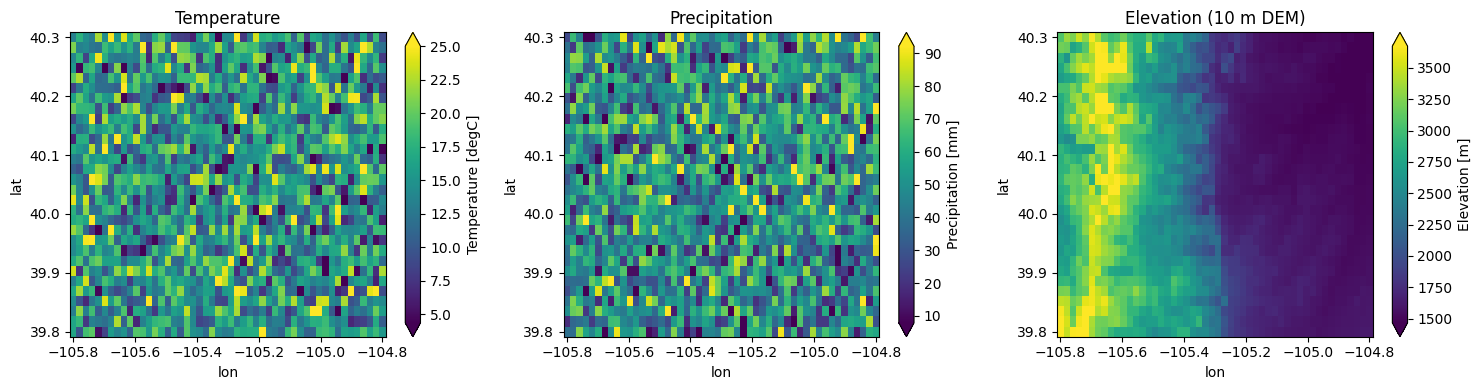

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ds["temperature"].plot(ax=axes[0], robust=True)
axes[0].set_title("Temperature")

ds["precipitation"].plot(ax=axes[1], robust=True)
axes[1].set_title("Precipitation")

ds["elevation"].plot(ax=axes[2], robust=True)
axes[2].set_title("Elevation (10 m DEM)")

fig.tight_layout()
fig.savefig("images/elevation_grid.png")
plt.show()

## Using different resampling methods

By default `elevation_bygrid` uses bilinear interpolation
(`resampling=1`), but you can choose any DEM-applicable method:

| Code | Method         | Notes                        |
|-----:|:---------------|:-----------------------------|
|    0 | nearest        | fastest, no interpolation    |
|    1 | bilinear       | good general-purpose default |
|    2 | cubic          | sharper than bilinear        |
|    3 | cubic_spline   | smooth spline interpolation  |
|    4 | lanczos        | high-quality windowed sinc   |

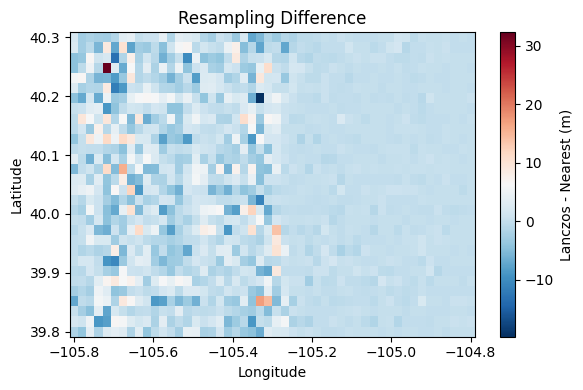

In [6]:
elev_nearest = s3dep.elevation_bygrid(longs, lats, resampling=0)
elev_lanczos = s3dep.elevation_bygrid(longs, lats, resampling=4)

diff = elev_lanczos - elev_nearest

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.pcolormesh(longs, lats, diff, cmap="RdBu_r", shading="auto")
fig.colorbar(im, ax=ax, label="Lanczos - Nearest (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Resampling Difference")
fig.tight_layout()
fig.savefig("images/resampling_diff.png")
plt.show()

## Sub-pixel interpolation

When the query grid is finer than the DEM pixel size (~10 m),
`elevation_bygrid` interpolates at the exact fractional pixel
position. This avoids the staircase/plateau artifacts that would
appear if each query point were simply snapped to the nearest pixel
center.

To demonstrate, we sample a small 200 m patch at 2 m spacing
(100 x 100 points) using bilinear and nearest-neighbour resampling.

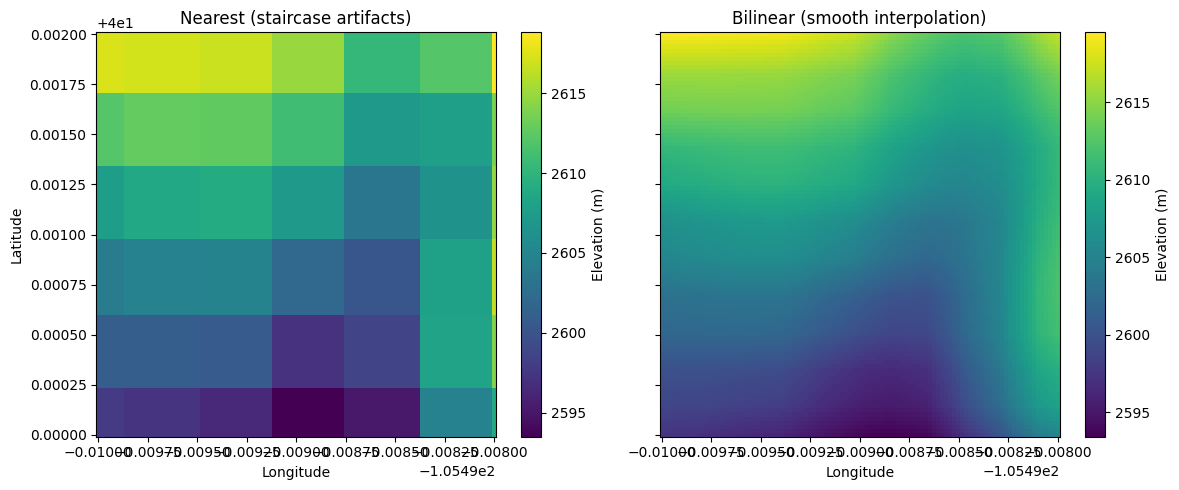

In [7]:
# ~200 m patch at ~2 m spacing (much finer than the 10 m DEM)
fine_longs = np.linspace(-105.5, -105.498, 100)
fine_lats = np.linspace(40.0, 40.002, 100)

elev_bilinear = s3dep.elevation_bygrid(fine_longs, fine_lats, resampling=1)
elev_nearest = s3dep.elevation_bygrid(fine_longs, fine_lats, resampling=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

im0 = axes[0].pcolormesh(fine_longs, fine_lats, elev_nearest, shading="auto")
fig.colorbar(im0, ax=axes[0], label="Elevation (m)")
axes[0].set_title("Nearest (staircase artifacts)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

im1 = axes[1].pcolormesh(fine_longs, fine_lats, elev_bilinear, shading="auto")
fig.colorbar(im1, ax=axes[1], label="Elevation (m)")
axes[1].set_title("Bilinear (smooth interpolation)")
axes[1].set_xlabel("Longitude")

fig.tight_layout()
fig.savefig("images/subpixel_interpolation.png")
plt.show()